# Skin Lesion Classification Using Convolutional Neural Network (CNN)

## Objective
The objective of this project is to classify skin lesions as Benign or Malignant using a Convolutional Neural Network (CNN).
Data augmentation is used to improve the performance of the model.

In [ ]:
# Import Required Libraries

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nityagupta12","key":"31bc7a3e90d2f82db2e3261288c72693"}'}

In [3]:
import os
import shutil

# Create Kaggle folder
os.makedirs('/root/.kaggle', exist_ok=True)

# Move kaggle.json to Kaggle folder
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')

# Set permissions
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("Kaggle API configured successfully!")

Kaggle API configured successfully!


In [4]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [03:20<00:00, 27.9MB/s]



In [5]:
!unzip -q skin-cancer-mnist-ham10000.zip -d dataset

In [6]:
import os

print(os.listdir("dataset"))

['HAM10000_images_part_2', 'hmnist_8_8_RGB.csv', 'hmnist_28_28_RGB.csv', 'hmnist_28_28_L.csv', 'HAM10000_images_part_1', 'ham10000_images_part_2', 'HAM10000_metadata.csv', 'hmnist_8_8_L.csv', 'ham10000_images_part_1']


In [7]:
import pandas as pd

metadata = pd.read_csv("dataset/HAM10000_metadata.csv")

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [8]:
# Convert 7 classes into 2 classes

benign = ['nv', 'bkl', 'df', 'vasc']
malignant = ['mel', 'bcc', 'akiec']

metadata['label'] = metadata['dx'].apply(
    lambda x: 'Benign' if x in benign else 'Malignant'
)

metadata[['dx', 'label']].head()

,dx,label
0,bkl,Benign
1,bkl,Benign
2,bkl,Benign
3,bkl,Benign
4,bkl,Benign


In [9]:
# Count images in each class

metadata['label'].value_counts()

,count
label,
Benign,8061
Malignant,1954


In [11]:
import os

image_path = {}

for folder in ['ham10000_images_part_1', 'ham10000_images_part_2']:
    folder_path = os.path.join('dataset', folder)

    for img in os.listdir(folder_path):
        image_id = img.split('.')[0]
        image_path[image_id] = os.path.join(folder_path, img)

metadata['path'] = metadata['image_id'].map(image_path)

metadata[['image_id', 'path']].head()

,image_id,path
0,ISIC_0027419,dataset/ham10000_images_part_1/ISIC_0027419.jpg
1,ISIC_0025030,dataset/ham10000_images_part_1/ISIC_0025030.jpg
2,ISIC_0026769,dataset/ham10000_images_part_1/ISIC_0026769.jpg
3,ISIC_0025661,dataset/ham10000_images_part_1/ISIC_0025661.jpg
4,ISIC_0031633,dataset/ham10000_images_part_2/ISIC_0031633.jpg


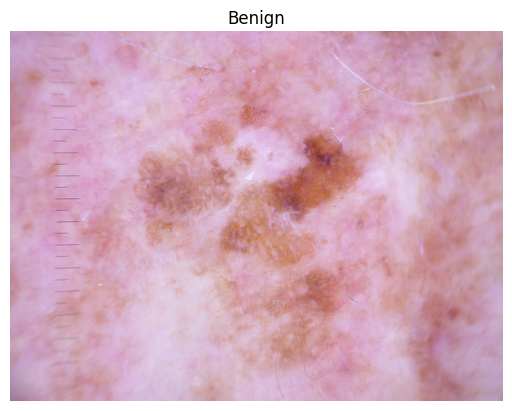

In [12]:
from PIL import Image
import matplotlib.pyplot as plt

# Display one sample image

img = Image.open(metadata['path'][0])

plt.imshow(img)
plt.title(metadata['label'][0])
plt.axis('off')
plt.show()

In [13]:
# Convert labels into numbers

metadata['target'] = metadata['label'].map({
    'Benign': 0,
    'Malignant': 1
})

metadata[['label', 'target']].head()

,label,target
0,Benign,0
1,Benign,0
2,Benign,0
3,Benign,0
4,Benign,0


In [14]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    metadata,
    test_size=0.2,
    random_state=42,
    stratify=metadata['target']
)

print("Training Images :", len(train_df))
print("Testing Images :", len(test_df))

Training Images : 8012
Testing Images : 2003


In [15]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

In [16]:
import tensorflow as tf

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, label

In [17]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_df['path'].values, train_df['target'].values)
)

train_dataset = train_dataset.map(load_image)
train_dataset = train_dataset.batch(BATCH_SIZE)

In [18]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_df['path'].values, test_df['target'].values)
)

test_dataset = test_dataset.map(load_image)
test_dataset = test_dataset.batch(BATCH_SIZE)

In [19]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')

])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 340s 1s/step - accuracy: 0.8049 - loss: 0.4522 - val_accuracy: 0.8048 - val_loss: 0.4852
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 374s 1s/step - accuracy: 0.8054 - loss: 0.4150 - val_accuracy: 0.8033 - val_loss: 0.4336
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - accuracy: 0.8079 - loss: 0.3951 - val_accuracy: 0.8063 - val_loss: 0.4043
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 330s 1s/step - accuracy: 0.8140 - loss: 0.3814 - val_accuracy: 0.8203 - val_loss: 0.4001
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 324s 1s/step - accuracy: 0.8301 - loss: 0.3589 - val_accuracy: 0.8218 - val_loss: 0.3930
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 376s 1s/step - accuracy: 0.8325 - loss: 0.3521 - val_accuracy: 0.8283 - val_loss: 0.3749
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 341s 1s/step - accuracy: 0.8425 - loss: 0.3331 - val_accuracy: 0.8253 - val_loss: 0.4342
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 382s 1s/step - accuracy: 0.8471 - loss: 0.3177 - val_accu

In [22]:
loss, accuracy = model.evaluate(test_dataset)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 459ms/step - accuracy: 0.8188 - loss: 0.4216
Test Loss: 0.42163869738578796
Test Accuracy: 0.8187718391418457


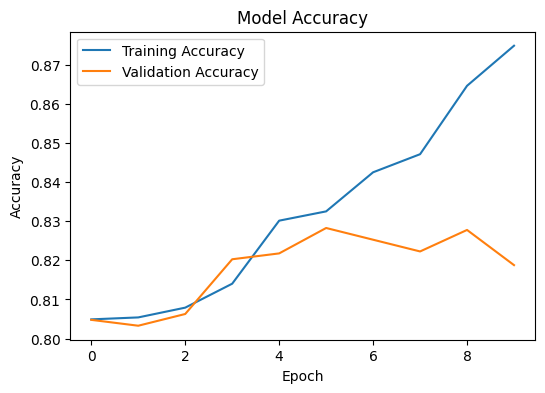

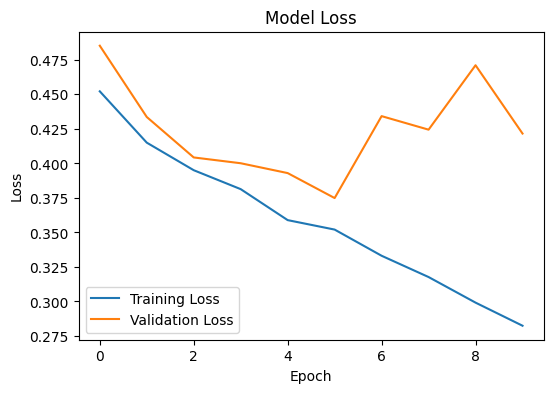

In [23]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss Graph
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [24]:
model.save("skin_lesion_cnn_model.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
Prediction : Benign
Actual : Malignant


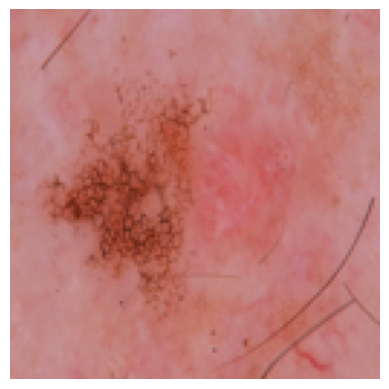

In [25]:
from PIL import Image
import numpy as np

# Sample image
sample_path = test_df.iloc[0]['path']

image = Image.open(sample_path).resize((128,128))
image_array = np.array(image) / 255.0
image_array = np.expand_dims(image_array, axis=0)

prediction = model.predict(image_array)

if prediction[0][0] >= 0.5:
    print("Prediction : Malignant")
else:
    print("Prediction : Benign")

print("Actual :", test_df.iloc[0]['label'])

plt.imshow(image)
plt.axis("off")
plt.show()

In [26]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

In [27]:
model = tf.keras.Sequential([

    data_augmentation,

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')

])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [34]:
# history = model.fit(
#     train_dataset,
#     validation_data=test_dataset,
#     epochs=5
# )


history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 370s 1s/step - accuracy: 0.5865 - loss: 0.5787 - val_accuracy: 0.5467 - val_loss: 0.5780
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 369s 1s/step - accuracy: 0.5668 - loss: 0.5669 - val_accuracy: 0.5726 - val_loss: 0.5113
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 345s 1s/step - accuracy: 0.6103 - loss: 0.5415 - val_accuracy: 0.5946 - val_loss: 0.5412
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 385s 1s/step - accuracy: 0.6402 - loss: 0.5305 - val_accuracy: 0.6965 - val_loss: 0.4751
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 361s 1s/step - accuracy: 0.6503 - loss: 0.5220 - val_accuracy: 0.6990 - val_loss: 0.4686


In [35]:
import numpy as np

y_true = test_df['target'].values

y_pred_prob = model.predict(test_dataset)
y_pred = (y_pred_prob > 0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 42s 634ms/step


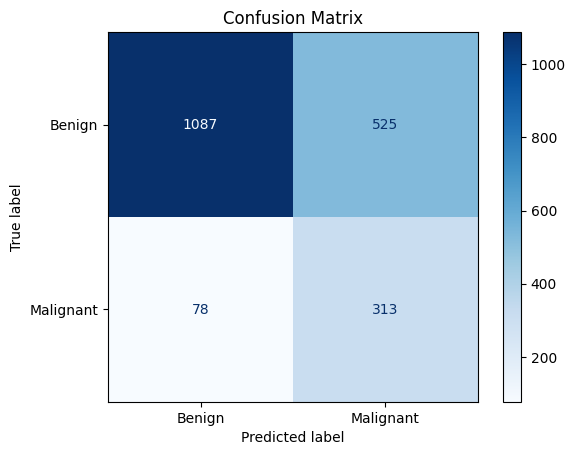

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [37]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["Benign", "Malignant"]
))

              precision    recall  f1-score   support

      Benign       0.93      0.67      0.78      1612
   Malignant       0.37      0.80      0.51       391

    accuracy                           0.70      2003
   macro avg       0.65      0.74      0.65      2003
weighted avg       0.82      0.70      0.73      2003



In [38]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['target']),
    y=train_df['target']
)

class_weights = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weights)

{0: np.float64(0.6211815785393084), 1: np.float64(2.563019833653231)}
